In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('/content/Crop_recommendation.csv')
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
X = data[['temperature', 'rainfall', 'humidity', 'ph']]
X

,temperature,rainfall,humidity,ph
0,20.879744,202.935536,82.002744,6.502985
1,21.770462,226.655537,80.319644,7.038096
2,23.004459,263.964248,82.320763,7.840207
3,26.491096,242.864034,80.158363,6.980401
4,20.130175,262.717340,81.604873,7.628473
...,...,...,...,...
2195,26.774637,177.774507,66.413269,6.780064
2196,27.417112,127.924610,56.636362,6.086922
2197,24.131797,173.322839,67.225123,6.362608
2198,26.272418,127.175293,52.127394,6.758793


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Initialize KMeans
kmeans = KMeans(n_clusters=22, random_state=42)  # You can adjust the number of clusters as needed

In [ ]:
# Fit KMeans clustering algorithm to the data
kmeans.fit(X_scaled)

KMeans(n_clusters=22, random_state=42)

In [ ]:
# Add the cluster labels to the original dataset
data['cluster'] = kmeans.labels_

In [ ]:
# Visualize the clusters
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

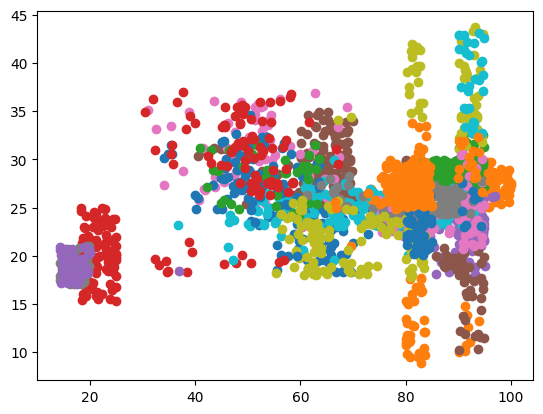

In [ ]:
# Scatter plot for each cluster
for cluster_num in sorted(data['cluster'].unique()):
    cluster_data = data[data['cluster'] == cluster_num]
    plt.scatter(cluster_data['humidity'], cluster_data['temperature'], label=f'Cluster {cluster_num}')

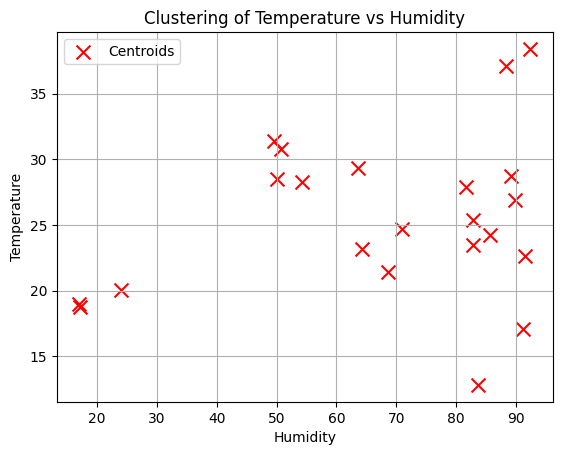

In [ ]:
# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 2], centroids[:, 0], marker='x', s=100, color='red', label='Centroids')

plt.xlabel('Humidity')
plt.ylabel('Temperature')
plt.title('Clustering of Temperature vs Humidity')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the clustered data to a CSV file
data.to_csv('clustered_data.csv', index=False)

In [ ]:
#Now read data from user and predict the crop
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load and Prepare the Dataset
dataset = pd.read_csv('/content/crop_dataset.csv')  # Load your crop dataset

# Step 2: Feature Selection
features = ['temperature', 'rainfall', 'humidity', 'ph']  # Select relevant features

# Step 3: Train the KMeans Model
X = dataset[features]  # Select features for training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=22, random_state=42)  # Assuming 5 clusters, adjust as needed
kmeans.fit(X_scaled)

# Step 4: Predict Crop Type
def predict_crop(user_input):
    user_df = pd.DataFrame([user_input])
    user_scaled = scaler.transform(user_df)
    predicted_cluster = kmeans.predict(user_scaled)

    # Define crop types for each cluster (you may need to adjust this based on your data)
    crop_types = {
        0: "Moothbeans",
        1: "Wheat,Jute,Coconut",
        2: "Moongbeans,Muskmelon",
        3: "Kidneybeans",
        4: "Pomegranate,apple",
        5:"Blackgram,Lentil",
        6:"Pigeonpeas,Moothbeans,Mango",
        7:"Chickpea",
        8:"Orange,Papaya",
        9:"Rice,Jute,Coffee",
        10:"Pigeonpeas,Mango",
        11:"Not suitable for any crop",
        12:"Moothbeans",
        13:"Pigeonpeas,Mango,Coffee",
        14:"Chickpea",
        15:"Pomegranate,Orange",
        16:"Pomegranate,Orange,Cotton",
        17:"Lentil,Watermelon,Cotton",
        18:"Maize,Lentil,Grapes",
        19:"Papaya",
        20:"Rice,Papaya",
        21:"Maize,Banana,Grapes,Orange",
        22:"Not suitable for any crop"

    }

    predicted_crop = crop_types[predicted_cluster[0]]
    return predicted_crop, predicted_cluster[0]

# Step 5: Display Results and Visualization
user_input = {
    'temperature': float(input("Enter temperature: ")),
    'rainfall': float(input("Enter rainfall: ")),
    'humidity': float(input("Enter humidity: ")),
    'ph': float(input("Enter pH: "))
}

predicted_crop, predicted_cluster = predict_crop(user_input)
print("Predicted Crop Type:", predicted_crop)

# Visualize the clusters
plt.figure(figsize=(10, 6))




Enter temperature: 32
Enter rainfall: 100
Enter humidity: 0.2
Enter pH: 4
Predicted Crop Type: Pigeonpeas,Moothbeans,Mango


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>